# Datathon Passos Mágicos — Análise Exploratória (11 perguntas)

**Base:** `data/processed/pede_unificado.csv` — painel longo aluno × ano (2022–2024),
3.030 avaliações, 1.661 alunos, indicadores na escala 0–10.

**Decisões metodológicas relevantes** (detalhes em `planning/achados_limpeza.md`):
- `defas = fase − fase_ideal` → **negativo = aluno atrasado**. O IAN é função
  determinística da defasagem: 2,5 = severa (≤ −3), 5 = moderada (−2/−1), 10 = em fase.
- `em_risco = defas < 0` (aluno defasado; ≡ IAN ≤ 5) — definição fixa e comparável entre anos.
- O IPP de 2022 é **reconstruído algebricamente** a partir da fórmula do INDE
  (validada contra 2023/2024 com resíduo ≈ 0); interpretações do IPP 2022 carregam essa ressalva.
- Colunas de texto livre (recomendações de avaliadores) existem só em 2022 — uso qualitativo.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GroupKFold

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/processed/pede_unificado.csv')
ev = pd.read_csv('../data/processed/evasao.csv')

# em_risco/atingiu_pv voltam do CSV como object (True/False/vazio) -> boolean com NA
for c in ('em_risco', 'atingiu_pv'):
    df[c] = df[c].map(lambda v: pd.NA if pd.isna(v) else v in (True, 'True')).astype('boolean')

IND = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde']
print(f'{df.shape[0]} avaliações | {df.id_aluno.nunique()} alunos | anos: {sorted(df.ano.unique())}')
df.groupby('ano').size()

3030 avaliações | 1661 alunos | anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


ano
2022     860
2023    1014
2024    1156
dtype: int64

## P1 — Qual o perfil de defasagem escolar (IAN) e como evoluiu?

Método: taxa e severidade da defasagem por ano (categorias oficiais do IAN) e
IAN médio por ano × fase.

Distribuição da defasagem por ano (%):
cat   severa  moderada  em fase
ano                            
2022     3.3      66.6     30.1
2023     1.4      53.1     45.6
2024     0.3      45.9     53.8

Taxa de alunos defasados (em_risco):
ano
2022    69.9%
2023    54.4%
2024    47.8%
Name: em_risco, dtype: str


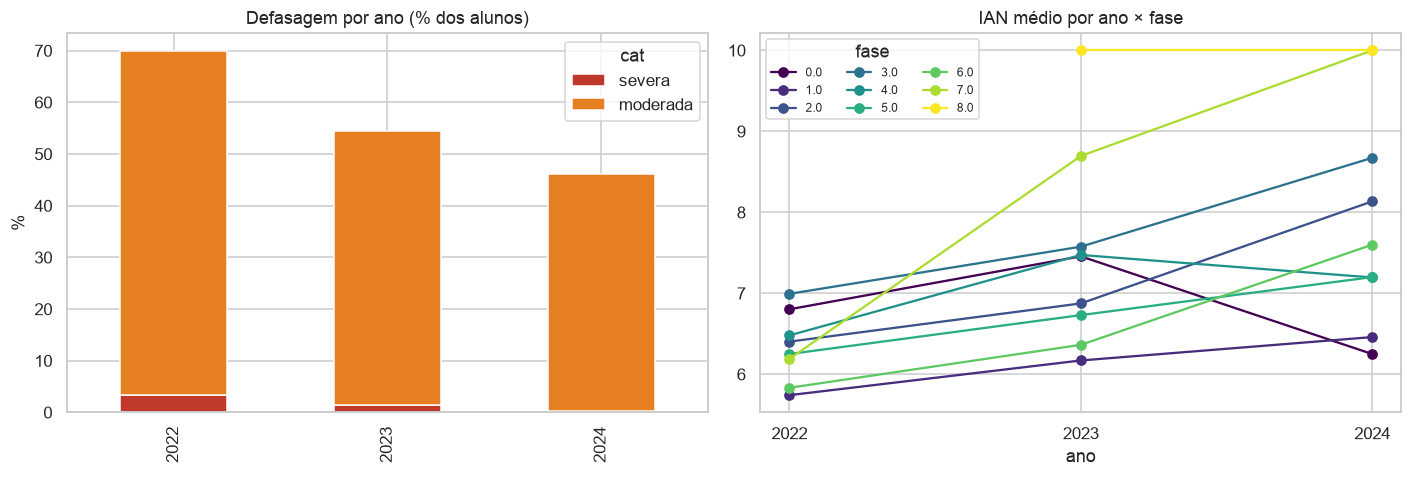

In [2]:
cat = np.select([df.ian == 2.5, df.ian == 5], ['severa', 'moderada'], default='em fase')
sev = df.assign(cat=pd.Categorical(cat, ['severa', 'moderada', 'em fase'])) \
        .groupby(['ano', 'cat'], observed=False).size().unstack()
sev_pct = (sev.div(sev.sum(axis=1), axis=0) * 100).round(1)
print('Distribuição da defasagem por ano (%):')
print(sev_pct)
print()
tx = df.groupby('ano')['em_risco'].mean().mul(100).round(1)
print('Taxa de alunos defasados (em_risco):')
print(tx.astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sev_pct[['severa', 'moderada']].plot(kind='bar', stacked=True,
    color=['#c0392b', '#e67e22'], ax=axes[0])
axes[0].set_title('Defasagem por ano (% dos alunos)')
axes[0].set_ylabel('%'); axes[0].set_xlabel('')

piv = df.pivot_table(index='ano', columns='fase', values='ian')
piv.plot(marker='o', ax=axes[1], colormap='viridis')
axes[1].set_title('IAN médio por ano × fase')
axes[1].set_xticks([2022, 2023, 2024])
axes[1].legend(title='fase', ncol=3, fontsize=8)
plt.tight_layout()

**Leitura:** a defasagem cai de forma consistente — 69,9% (2022) → 54,4% (2023) →
47,8% (2024) — e a defasagem **severa** encolhe ainda mais rápido. A melhora aparece
em praticamente todas as fases (painel direito). Este é o achado central do storytelling:
o programa está revertendo defasagem ano a ano.

## P2 — O desempenho acadêmico (IDA) está melhorando, estagnado ou caindo?

Método: IDA médio por ano × fase + regressão linear `ida ~ ano` por fase
(inclinação e p-valor), para responder com números e não só com o gráfico.

 fase   n  inclinacao_por_ano  p_valor
  0.0 617              0.0890   0.3081
  1.0 550              0.1643   0.0884
  2.0 539              0.3920   0.0002
  3.0 491              0.0786   0.4299
  4.0 285             -0.0895   0.4649
  5.0 225              0.3096   0.0560
  6.0  76              0.2788   0.1518
  7.0  68              0.1801   0.6243

Geral: inclinação = +0.114 pts/ano (p = 1.08e-02)


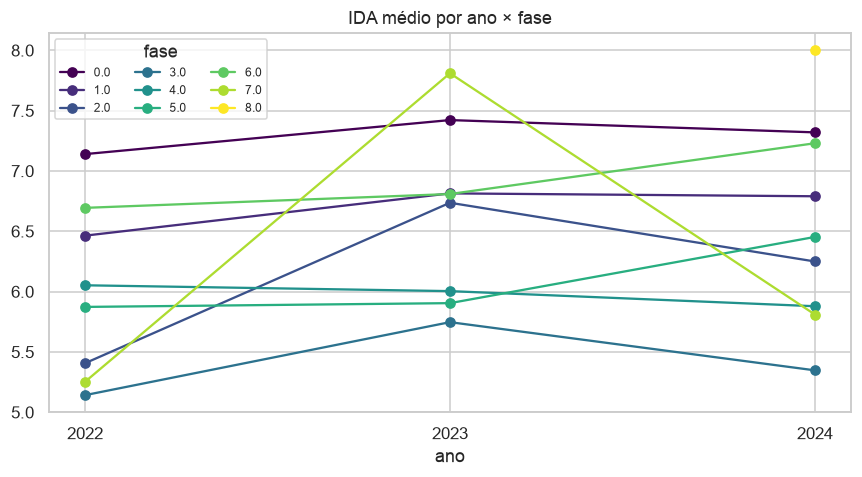

In [3]:
piv2 = df.pivot_table(index='ano', columns='fase', values='ida')
ax = piv2.plot(marker='o', figsize=(8, 4.5), colormap='viridis')
ax.set_title('IDA médio por ano × fase'); ax.set_xticks([2022, 2023, 2024])
ax.legend(title='fase', ncol=3, fontsize=8)
plt.tight_layout()

rows = []
base2 = df.dropna(subset=['ida'])
r_all = stats.linregress(base2['ano'], base2['ida'])
for fase, g in base2.groupby('fase'):
    if g['ano'].nunique() >= 2:
        r = stats.linregress(g['ano'], g['ida'])
        rows.append((fase, len(g), r.slope, r.pvalue))
trend = pd.DataFrame(rows, columns=['fase', 'n', 'inclinacao_por_ano', 'p_valor']).round(4)
print(trend.to_string(index=False))
print(f'\nGeral: inclinação = {r_all.slope:+.3f} pts/ano (p = {r_all.pvalue:.2e})')

## P3 — Alunos mais engajados (IEG) apresentam melhor desempenho (IDA) e ponto de virada (IPV)?

Método: correlações de Pearson e Spearman IEG×IDA e IEG×IPV, por ano e no total,
com dispersão + linha de tendência.

    par   ano  pearson  spearman    n
IEG×IDA  2022    0.564     0.507  860
IEG×IDA  2023    0.461     0.446  937
IEG×IDA  2024    0.547     0.519 1054
IEG×IDA todos    0.543     0.499 2851
IEG×IPV  2022    0.589     0.540  860
IEG×IPV  2023    0.449     0.492  938
IEG×IPV  2024    0.535     0.551 1054
IEG×IPV todos    0.558     0.546 2852


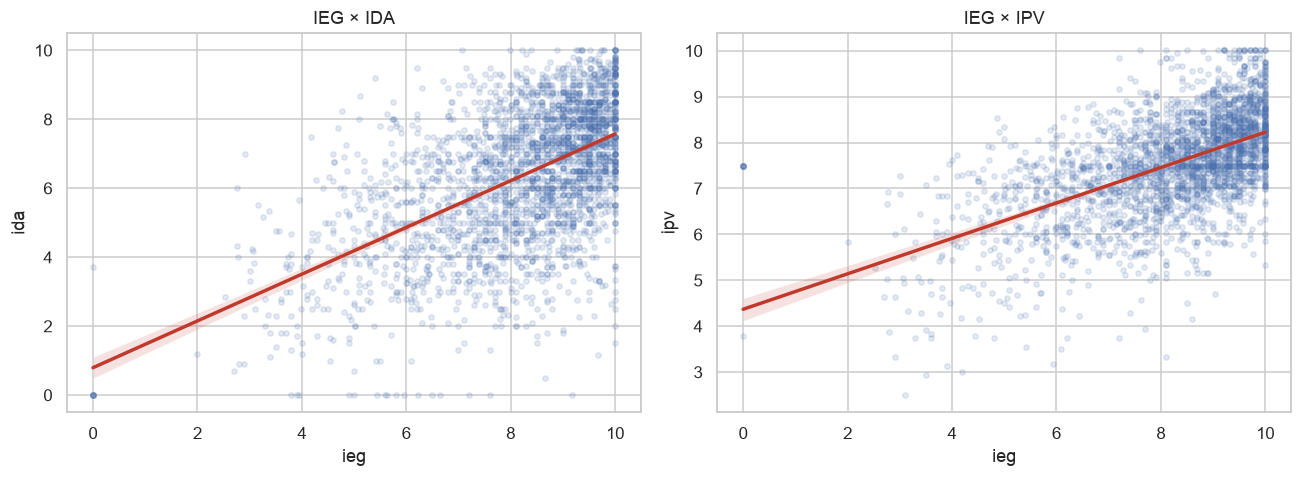

In [4]:
def tabela_corr(pares):
    rows = []
    for x, y in pares:
        for ano, g in df.dropna(subset=[x, y]).groupby('ano'):
            rows.append((f'{x.upper()}×{y.upper()}', ano,
                         g[x].corr(g[y]), g[x].corr(g[y], method='spearman'), len(g)))
        g = df.dropna(subset=[x, y])
        rows.append((f'{x.upper()}×{y.upper()}', 'todos',
                     g[x].corr(g[y]), g[x].corr(g[y], method='spearman'), len(g)))
    return pd.DataFrame(rows, columns=['par', 'ano', 'pearson', 'spearman', 'n']).round(3)

print(tabela_corr([('ieg', 'ida'), ('ieg', 'ipv')]).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, ycol in zip(axes, ['ida', 'ipv']):
    sns.regplot(data=df, x='ieg', y=ycol, ax=ax,
                scatter_kws={'alpha': 0.15, 's': 12}, line_kws={'color': '#c0392b'})
    ax.set_title(f'IEG × {ycol.upper()}')
plt.tight_layout()

## P4 — A autoavaliação (IAA) dos alunos está alinhada com o desempenho real?

Método: correlação IAA×IDA e IAA×IEG + análise do gap `iaa − ida`
(quem se autoavalia muito acima/abaixo do que entrega).

    par   ano  pearson  spearman    n
IAA×IDA  2022    0.209     0.183  860
IAA×IDA  2023    0.105     0.127  937
IAA×IDA  2024    0.220     0.178 1054
IAA×IDA todos    0.115     0.151 2851
IAA×IEG  2022    0.323     0.234  860
IAA×IEG  2023    0.170     0.191  938
IAA×IEG  2024    0.230     0.230 1054
IAA×IEG todos    0.133     0.181 2852

Gap médio (IAA − IDA): +1.55 | mediana: +1.80
|gap| >= 3 pontos: 39.2% das avaliações
gap >= +3 (autoimagem muito acima do desempenho): 31.0%

Maiores gaps positivos (se veem muito melhor do que o IDA mostra):
 id_aluno  ano  fase   iaa  ida   gap
      294 2022   3.0 9.600  0.0 9.600
     1229 2024   7.0 9.168  0.0 9.168
      270 2024   7.0 9.168  0.0 9.168
     1311 2024   0.0 9.002  0.0 9.002
     1392 2024   0.0 9.002  0.0 9.002


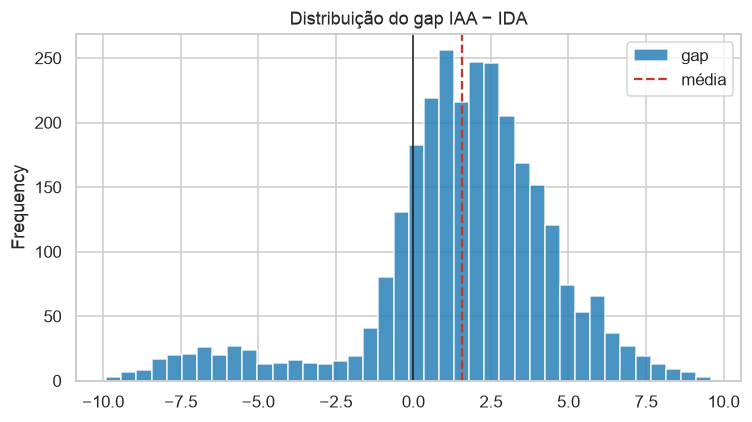

In [5]:
print(tabela_corr([('iaa', 'ida'), ('iaa', 'ieg')]).to_string(index=False))

g4 = df.dropna(subset=['iaa', 'ida']).assign(gap=lambda d: d.iaa - d.ida)
print(f"\nGap médio (IAA − IDA): {g4.gap.mean():+.2f} | mediana: {g4.gap.median():+.2f}")
print(f"|gap| >= 3 pontos: {(g4.gap.abs() >= 3).mean()*100:.1f}% das avaliações")
print(f"gap >= +3 (autoimagem muito acima do desempenho): {(g4.gap >= 3).mean()*100:.1f}%")

ax = g4.gap.plot(kind='hist', bins=40, figsize=(7, 4), color='#2980b9', alpha=0.85)
ax.axvline(0, color='k', lw=1); ax.axvline(g4.gap.mean(), color='#c0392b', ls='--', label='média')
ax.set_title('Distribuição do gap IAA − IDA'); ax.legend()
plt.tight_layout()

print('\nMaiores gaps positivos (se veem muito melhor do que o IDA mostra):')
print(g4.nlargest(5, 'gap')[['id_aluno', 'ano', 'fase', 'iaa', 'ida', 'gap']].to_string(index=False))

## P5 — O IPS (psicossocial) antecede quedas de desempenho ou engajamento?

Método: para cada aluno com dois anos consecutivos, correlaciona IPS(t) com a
**variação** de IDA e IEG entre t e t+1. Se IPS baixo antecipa queda, a correlação
é positiva (IPS baixo → Δ negativo).

pares consecutivos com IPS e Δ IDA: 1253
IPS(t) × d_ida(t→t+1): pearson = +0.120 (p = 1.99e-05, n = 1253)
IPS(t) × d_ieg(t→t+1): pearson = +0.198 (p = 1.4e-12, n = 1252)

Δ IDA médio por quartil de IPS(t):
             mean  count
ips_grupo               
Q1 (baixo) -0.461    421
Q2         -0.270    206
Q3          0.222    367
Q4 (alto)  -0.360    259


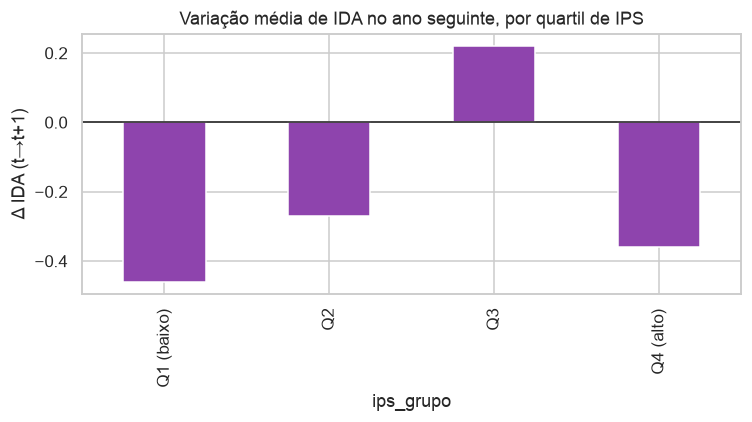

In [6]:
nxt = df[['id_aluno', 'ano', 'ida', 'ieg']].copy()
nxt['ano'] -= 1
p5 = df.merge(nxt, on=['id_aluno', 'ano'], suffixes=('', '_t1'))
p5['d_ida'] = p5.ida_t1 - p5.ida
p5['d_ieg'] = p5.ieg_t1 - p5.ieg
b5 = p5.dropna(subset=['ips', 'd_ida'])
print(f'pares consecutivos com IPS e Δ IDA: {len(b5)}')
for dcol in ['d_ida', 'd_ieg']:
    b = p5.dropna(subset=['ips', dcol])
    r, p = stats.pearsonr(b.ips, b[dcol])
    print(f'IPS(t) × {dcol}(t→t+1): pearson = {r:+.3f} (p = {p:.3g}, n = {len(b)})')

b5['ips_grupo'] = pd.qcut(b5.ips, 4, labels=['Q1 (baixo)', 'Q2', 'Q3', 'Q4 (alto)'])
print('\nΔ IDA médio por quartil de IPS(t):')
print(b5.groupby('ips_grupo', observed=True)['d_ida'].agg(['mean', 'count']).round(3))

ax = b5.groupby('ips_grupo', observed=True)['d_ida'].mean().plot(
    kind='bar', figsize=(7, 4), color='#8e44ad')
ax.axhline(0, color='k', lw=1)
ax.set_title('Variação média de IDA no ano seguinte, por quartil de IPS')
ax.set_ylabel('Δ IDA (t→t+1)')
plt.tight_layout()

## P6 — As avaliações psicopedagógicas (IPP) confirmam ou contradizem o IAN?

Método: IPP médio por categoria de defasagem (IAN) e por ano.
**Ressalva:** o IPP de 2022 é reconstruído algebricamente; a diferença de nível
2022 vs. 2023/24 (≈ 6,3 vs. ≈ 7,6) é um achado distribucional real, não erro de fórmula
(validação em `achados_limpeza.md`, achado 2).

IPP médio por categoria de defasagem × ano:
ano       2022  2023  2024
cat_ian                   
severa    6.47  6.96  7.26
moderada  6.18  7.50  7.41
em fase   6.50  7.67  7.69

Correlação defas × IPP: +0.239 (p = 3.3e-38, n = 2852)


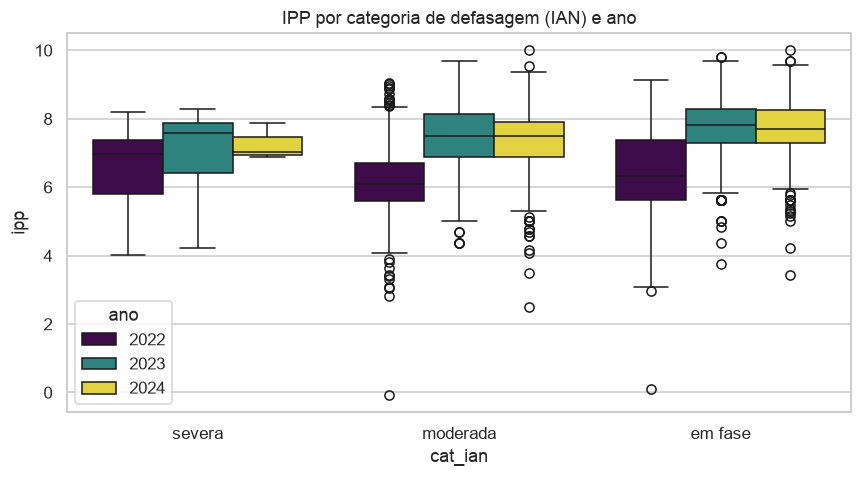

In [7]:
df['cat_ian'] = pd.Categorical(
    np.select([df.ian == 2.5, df.ian == 5], ['severa', 'moderada'], default='em fase'),
    ['severa', 'moderada', 'em fase'])

t6 = df.pivot_table(index='cat_ian', columns='ano', values='ipp', observed=False).round(2)
print('IPP médio por categoria de defasagem × ano:')
print(t6)
b6 = df.dropna(subset=['ipp', 'defas'])
r, p = stats.pearsonr(b6.defas, b6.ipp)
print(f'\nCorrelação defas × IPP: {r:+.3f} (p = {p:.3g}, n = {len(b6)})')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='cat_ian', y='ipp', hue='ano', ax=ax, palette='viridis')
ax.set_title('IPP por categoria de defasagem (IAN) e ano')
plt.tight_layout()

## P7 — O que mais influencia o IPV (ponto de virada)?

Método: coeficientes padronizados de regressão linear + importâncias de
RandomForest para `ipv ~ ieg + ida + ips + iaa + defas`, com R² validado por
GroupKFold (grupos = aluno, evita vazamento).

       coef_padronizado (LR)  importancia (RF)
ida                    0.387             0.366
ieg                    0.382             0.339
ips                   -0.042             0.125
iaa                   -0.025             0.122
defas                  0.084             0.048

R² (RandomForest, GroupKFold 5): 0.425 ± 0.026 (n = 2845)


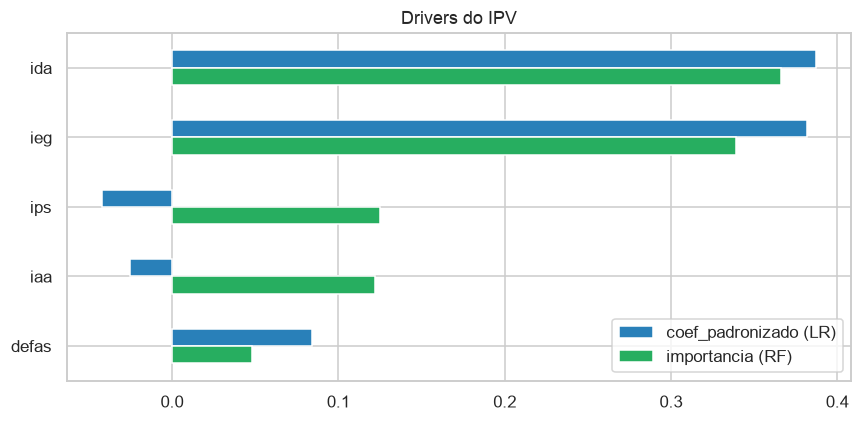

In [8]:
FEAT7 = ['ieg', 'ida', 'ips', 'iaa', 'defas']
b7 = df.dropna(subset=FEAT7 + ['ipv'])
X, y = b7[FEAT7], b7['ipv']

lr = LinearRegression().fit(StandardScaler().fit_transform(X), y)
coefs = pd.Series(lr.coef_, index=FEAT7)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X, y)
imps = pd.Series(rf.feature_importances_, index=FEAT7)
r2 = cross_val_score(rf, X, y, cv=GroupKFold(5), groups=b7.id_aluno, scoring='r2')

comp = pd.DataFrame({'coef_padronizado (LR)': coefs, 'importancia (RF)': imps}) \
         .sort_values('importancia (RF)', ascending=False).round(3)
print(comp)
print(f'\nR² (RandomForest, GroupKFold 5): {r2.mean():.3f} ± {r2.std():.3f} (n = {len(b7)})')

comp.plot(kind='barh', figsize=(8, 4), color=['#2980b9', '#27ae60'])
plt.title('Drivers do IPV'); plt.gca().invert_yaxis(); plt.tight_layout()

## P8 — Que combinações de indicadores mais elevam o INDE?

Método: importâncias de RandomForest prevendo `inde` a partir de IDA+IEG+IPS+IPP,
comparadas aos **pesos oficiais** da fórmula (IDA 0,2 / IEG 0,2 / IPS 0,1 / IPP 0,1) —
mostra quais dimensões carregam, na prática, a variação do índice.

     importancia_RF  peso_oficial
ida           0.566           0.2
ieg           0.277           0.2
ipp           0.085           0.1
ips           0.072           0.1

Correlação de cada indicador com o INDE:
ida    0.785
ieg    0.745
ipv    0.721
ipp    0.456
ian    0.405
iaa    0.397
ips    0.200
Name: inde, dtype: float64


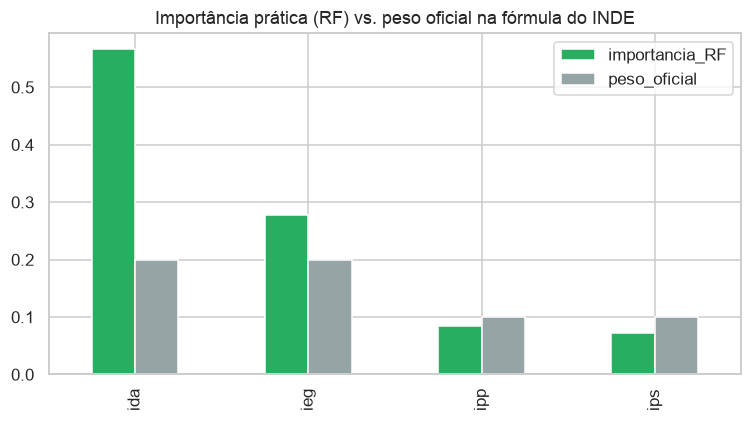

In [9]:
FEAT8 = ['ida', 'ieg', 'ips', 'ipp']
b8 = df.dropna(subset=FEAT8 + ['inde'])
rf8 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1) \
        .fit(b8[FEAT8], b8['inde'])
imp8 = pd.Series(rf8.feature_importances_, index=FEAT8, name='importancia_RF')
oficial = pd.Series({'ida': 0.2, 'ieg': 0.2, 'ips': 0.1, 'ipp': 0.1}, name='peso_oficial')
t8 = pd.concat([imp8, oficial], axis=1).sort_values('importancia_RF', ascending=False).round(3)
print(t8)

corr8 = df[IND].corr().loc[['ida', 'ieg', 'ips', 'ipp', 'iaa', 'ipv', 'ian'], 'inde'] \
          .sort_values(ascending=False)
print('\nCorrelação de cada indicador com o INDE:')
print(corr8.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
t8.plot(kind='bar', ax=ax, color=['#27ae60', '#95a5a6'])
ax.set_title('Importância prática (RF) vs. peso oficial na fórmula do INDE')
plt.tight_layout()

## P9 — É possível prever, com antecedência, alunos em risco de defasagem?

**Desenho early-warning (t→t+1):** prever se o aluno estará defasado no ano
seguinte usando os indicadores do ano corrente. Evita a circularidade de usar
IAN/defas do próprio ano-alvo (que *definem* o alvo).

Abaixo, a força de cada indicador do ano t como sinal do risco em t+1 — evidência
que motiva as features do modelo. O modelo completo (baseline logístico,
RandomForest e rede neural Keras) está em `02_modelagem.ipynb`.

pares t→t+1: 1352 | taxa de defasagem em t+1: 49.9%
defas           -0.465
ipp             -0.420
ian             -0.389
inde            -0.344
ipv             -0.337
ieg             -0.219
ida             -0.213
tempo_vinculo   -0.172
idade           -0.147
iaa              0.015
ips              0.157
dtype: float64


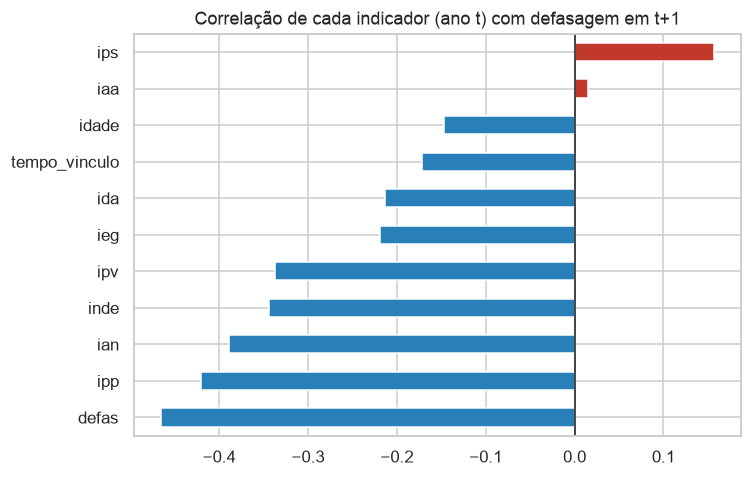

In [10]:
nxt9 = df[['id_aluno', 'ano', 'em_risco']].copy()
nxt9['ano'] -= 1
p9 = df.merge(nxt9, on=['id_aluno', 'ano'], suffixes=('', '_t1'))
p9 = p9[p9.em_risco_t1.notna()].copy()
p9['alvo'] = p9.em_risco_t1.astype(bool).astype(int)
print(f'pares t→t+1: {len(p9)} | taxa de defasagem em t+1: {p9.alvo.mean()*100:.1f}%')

sinais = {}
for c in IND + ['defas', 'idade', 'tempo_vinculo']:
    b = p9.dropna(subset=[c])
    sinais[c] = stats.pointbiserialr(b.alvo, b[c])[0]
s9 = pd.Series(sinais).sort_values()
ax = s9.plot(kind='barh', figsize=(7, 4.5),
             color=['#c0392b' if v > 0 else '#2980b9' for v in s9])
ax.set_title('Correlação de cada indicador (ano t) com defasagem em t+1')
ax.axvline(0, color='k', lw=1)
plt.tight_layout()
print(s9.round(3))

## P10 — O programa é efetivo? (evolução por fase e por coorte)

Método em duas camadas:
1. **Transversal** — INDE médio por fase × ano (médias podem mudar só por composição de turma).
2. **Longitudinal** — a trajetória dos **mesmos alunos** presentes nos 3 anos:
   se o aluno médio melhora consigo mesmo, a efetividade é real, não composição.

Alunos com INDE nos 3 anos (coorte fixa): 434
INDE médio da coorte fixa: {2022: 7.379, 2023: 7.349, 2024: 7.376}
Δ INDE 2022→2024 médio: -0.003 | melhoraram: 55.3%

Coorte com status de defasagem nos 3 anos: 468
% defasados na coorte fixa por ano: {2022: 67.3, 2023: 58.1, 2024: 34.8}


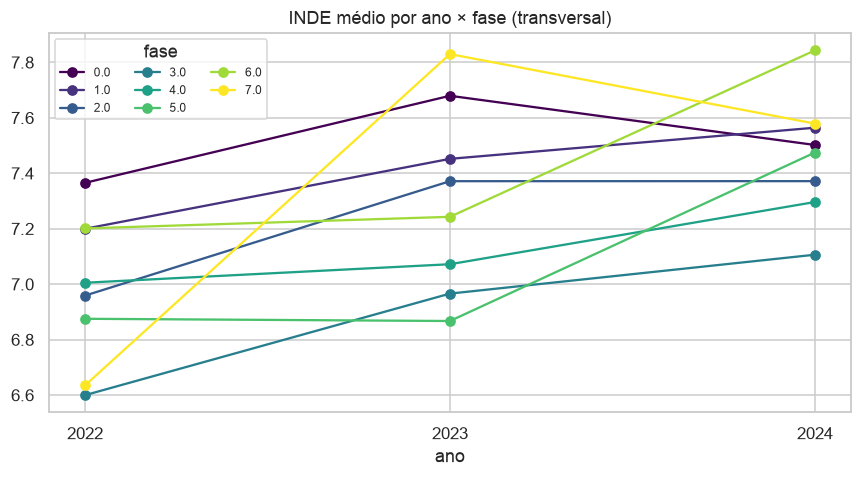

In [11]:
piv10 = df.pivot_table(index='ano', columns='fase', values='inde')
ax = piv10.plot(marker='o', figsize=(8, 4.5), colormap='viridis')
ax.set_title('INDE médio por ano × fase (transversal)')
ax.set_xticks([2022, 2023, 2024]); ax.legend(title='fase', ncol=3, fontsize=8)
plt.tight_layout()

w = df.pivot_table(index='id_aluno', columns='ano', values='inde')
coorte = w.dropna()
print(f'Alunos com INDE nos 3 anos (coorte fixa): {len(coorte)}')
print('INDE médio da coorte fixa:', coorte.mean().round(3).to_dict())
delta = coorte[2024] - coorte[2022]
print(f'Δ INDE 2022→2024 médio: {delta.mean():+.3f} | melhoraram: {(delta > 0).mean()*100:.1f}%')

r10 = df.assign(r=df.em_risco.astype('float')).pivot_table(index='id_aluno', columns='ano', values='r')
c10 = r10.dropna()
print(f'\nCoorte com status de defasagem nos 3 anos: {len(c10)}')
print('% defasados na coorte fixa por ano:', (c10.mean() * 100).round(1).to_dict())

## P11 — Insights adicionais

Três frentes: **(i)** evasão — quem sai da associação; **(ii)** o degrau do IPP
2022 vs. 2023/24; **(iii)** perfil dos indicados a bolsa em 2022.

In [12]:
# (i) Evasão: taxa por ano e perfil de quem evade (features do ano de referência)
e11 = ev.merge(df, left_on=['id_aluno', 'ano_referencia'], right_on=['id_aluno', 'ano'])
print('Taxa de evasão por ano de referência:')
print(ev.groupby('ano_referencia')['evadiu'].mean().mul(100).round(1).astype(str) + '%')
print('\nEvasão por fase (%):')
print(e11.groupby('fase')['evadiu'].agg([('taxa_%', lambda s: s.mean()*100), 'count']).round(1))
e11['faixa_idade'] = pd.cut(e11.idade, [5, 9, 12, 15, 25], labels=['6-9', '10-12', '13-15', '16+'])
print('\nEvasão por faixa de idade (%):')
print(e11.groupby('faixa_idade', observed=True)['evadiu'].agg([('taxa_%', lambda s: s.mean()*100), 'count']).round(1))
print('\nIndicadores médios: evadiu vs. permaneceu')
print(e11.groupby('evadiu')[['inde', 'ieg', 'ipv', 'defas', 'idade']].mean().round(2))

Taxa de evasão por ano de referência:
ano_referencia
2022    30.2%
2023    24.6%
Name: evadiu, dtype: str

Evasão por fase (%):
      taxa_%  count
fase               
0.0     23.5    421
1.0     23.3    365
2.0     25.4    355
3.0     36.1    280
4.0     31.2    170
5.0     33.6    125
6.0     43.1     51
7.0     29.5     44
8.0      6.3     63

Evasão por faixa de idade (%):
             taxa_%  count
faixa_idade               
6-9            23.9    373
10-12          23.6    674
13-15          30.4    516
16+            33.5    310

Indicadores médios: evadiu vs. permaneceu
        inde   ieg   ipv  defas  idade
evadiu                                
False   7.37  8.60  7.81  -0.72  12.19
True    6.76  7.57  7.27  -0.96  12.72


In [13]:
# (ii) Degrau do IPP e (iii) perfil de bolsa 2022
print('IPP médio por ano (2022 é reconstruído — ver ressalva na P6):')
print(df.groupby('ano')['ipp'].mean().round(2))

b22 = df[df.ano == 2022]
print('\nIndicadores médios 2022 por indicação a bolsa:')
print(b22.groupby('indicado_bolsa')[['inde', 'ida', 'ieg', 'iaa', 'ips', 'ipv', 'defas']].mean().round(2))
med_ind = b22.loc[b22.indicado_bolsa == 'Sim', 'inde'].median()
esquecidos = b22[(b22.indicado_bolsa == 'Não') & (b22.inde >= med_ind)]
print(f'\nNão indicados com INDE ≥ mediana dos indicados ({med_ind:.2f}): {len(esquecidos)} alunos')
print('— candidatos que o critério atual pode estar deixando de fora.')

IPP médio por ano (2022 é reconstruído — ver ressalva na P6):
ano
2022    6.28
2023    7.56
2024    7.55
Name: ipp, dtype: float64

Indicadores médios 2022 por indicação a bolsa:
                inde   ida   ieg   iaa   ips   ipv  defas
indicado_bolsa                                           
Não             6.97  5.95  7.86  8.31  6.85  7.14  -0.93
Sim             7.41  6.88  8.06  8.05  7.21  7.86  -0.99

Não indicados com INDE ≥ mediana dos indicados (7.59): 214 alunos
— candidatos que o critério atual pode estar deixando de fora.


## Síntese executiva

| # | Pergunta | Achado principal |
|---|----------|------------------|
| 1 | Defasagem (IAN) | Cai de **69,9% (2022) → 54,4% (2023) → 47,8% (2024)**; a severa quase desaparece (3,3% → 0,3%). |
| 2 | Desempenho (IDA) | Em alta: **+0,11 pt/ano** no geral (p = 0,011); fase 2 lidera com +0,39 pt/ano (p < 0,001). |
| 3 | Engajamento (IEG) | Confirma a hipótese: correlação **0,54 com IDA** e **0,56 com IPV** — estável nos 3 anos. |
| 4 | Autoavaliação (IAA) | Pouco alinhada ao desempenho (r ≈ 0,12 com IDA); autoimagem inflada: gap médio **+1,55**, e 31% dos alunos se avaliam ≥ 3 pontos acima do próprio IDA. |
| 5 | IPS antecede quedas | Sinal fraco porém significativo: IPS(t) × ΔIDA(t→t+1) r = +0,12 (p < 0,001); o quartil mais baixo de IPS tem a maior queda média de IDA no ano seguinte (−0,46). |
| 6 | IPP × IAN | **Confirma**: IPP cresce com a adequação de nível (corr defas×IPP = +0,24); o degrau 2022 (6,28) vs. 2023/24 (≈ 7,55) é achado distribucional, não erro de fórmula. |
| 7 | Drivers do IPV | **IDA (0,39) e IEG (0,38)** dominam, em coeficiente padronizado e importância RF; R² = 0,43 (GroupKFold). |
| 8 | Combinações → INDE | Na prática o **IDA carrega o índice** (importância 0,57 vs. peso oficial 0,20); IEG em 2º (0,28). |
| 9 | Previsão de risco | Viável: defas (−0,47), IPP (−0,42), IAN (−0,39) e INDE (−0,34) do ano t são sinais fortes do risco em t+1; base de 1.352 pares, alvo balanceado (49,9%). Modelo em `02_modelagem.ipynb`. |
| 10 | Efetividade | INDE médio da coorte fixa é estável (≈ 7,4), mas a defasagem **na mesma coorte** despenca: **67,3% → 58,1% → 34,8%** — efetividade real, não efeito de composição. |
| 11 | Insights | Evasão cai 30,2% → 24,6%; evadem mais os **mais velhos (16+: 33,5%)** e as **fases 3–6 (até 43%)**; quem evade tem INDE/IEG bem menores (6,76/7,57 vs. 7,37/8,60). Bolsa 2022: **214 não indicados** tinham INDE ≥ mediana dos indicados — o critério pode estar deixando gente de fora. |

**Fio condutor do storytelling:** o programa reduz defasagem de forma consistente e
mensurável (P1, P10), o engajamento é a alavanca que conecta tudo (P3, P7), e é
possível antecipar quem vai se defasar (P9) — o modelo early-warning e o dashboard
transformam esse achado em ferramenta operacional para a associação.